# Diff-Pruning — DDPM CIFAR-10

In [ ]:
!git clone --branch clean https://github.com/elliotcanter11/Diff-Pruning.git

Cloning into 'Diff-Pruning'...
remote: Enumerating objects: 1077, done.
remote: Counting objects: 100% (493/493), done.
remote: Compressing objects: 100% (318/318), done.
remote: Total 1077 (delta 250), reused 348 (delta 152), pack-reused 584 (from 1)
Receiving objects: 100% (1077/1077), 26.93 MiB | 9.35 MiB/s, done.
Resolving deltas: 100% (496/496), done.


In [ ]:
%cd Diff-Pruning/

/content/Diff-Pruning


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 8.0 MB/s eta 0:00:00


## Data & pretrained model

In [ ]:
# Download and extract CIFAR-10 images to data/cifar10_images for training and evaluation.
!python tools/extract_cifar10_hug.py --output data

README.md: 100% 5.16k/5.16k [00:00<00:00, 9.09MB/s]

plain_text/train-00000-of-00001.parquet: downloading bytes:  85% 102M/120M [00:01<00:00, 101MB/s, 7.29MB/s  ]  
plain_text/train-00000-of-00001.parquet: downloading bytes: 100% 117M/117M [00:02<00:00, 53.8MB/s, 11.0MB/s  ]
plain_text/train-00000-of-00001.parquet: reconstructing file: 100% 120M/120M [00:02<00:00, 55.2MB/s, 11.4MB/s  ]

plain_text/test-00000-of-00001.parquet: downloading bytes:  41% 9.86M/23.9M [00:01<00:01, 9.87MB/s, 17.9kB/s  ]
plain_text/test-00000-of-00001.parquet: downloading bytes: 100% 23.3M/23.3M [00:01<00:00, 15.7MB/s, 2.25MB/s  ]
plain_text/test-00000-of-00001.parquet: reconstructing file: 100% 23.9M/23.9M [00:01<00:00, 16.2MB/s, 2.32MB/s  ]
Generating train split: 100% 50000/50000 [00:00<00:00, 179492.29 examples/s]
Generating test split: 100% 10000/10000 [00:00<00:00, 206011.12 examples/s]
100% 50000/50000 [00:29<00:00, 1684.71it/s]


In [ ]:
# Download an official DDPM model and convert it to the Huggingface Diffusers format.
# The converted (EMA) model of google/ddpm-cifar10-32 lands in pretrained/ddpm_ema_cifar10.
!bash tools/convert_cifar10_ddpm_ema.sh

--2026-07-20 15:28:56--  https://heibox.uni-heidelberg.de/f/2e4f01e2d9ee49bab1d5/?dl=1
Resolving heibox.uni-heidelberg.de (heibox.uni-heidelberg.de)... 129.206.7.113
Connecting to heibox.uni-heidelberg.de (heibox.uni-heidelberg.de)|129.206.7.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://heibox.uni-heidelberg.de/seafhttp/files/744efc91-c4bd-49a3-a06f-632977c57bec/model-790000.ckpt [following]
--2026-07-20 15:28:57--  https://heibox.uni-heidelberg.de/seafhttp/files/744efc91-c4bd-49a3-a06f-632977c57bec/model-790000.ckpt
Reusing existing connection to heibox.uni-heidelberg.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 143046049 (136M) [application/octet-stream]
Saving to: ‘pretrained/cifar10-ema-model-790000.ckpt’

pretrained/cifar10- 100%[===================>] 136.42M  7.67MB/s    in 18s     

2026-07-20 15:29:16 (7.44 MB/s) - ‘pretrained/cifar10-ema-model-790000.ckpt’ saved [143046049/143046049]

Flax classes are deprecated an

In [ ]:
!python ddpm_sample.py --output_dir run/sample/ddpm_cifar10_pretrained --batch_size 16 --total_samples 16 --model_path pretrained/ddpm_ema_cifar10


Loading model from pretrained/ddpm_ema_cifar10
The config attributes {'attn_norm_num_groups': None, 'downsample_type': 'conv', 'dropout': 0.0, 'mid_block_type': 'UNetMidBlock2D', 'num_train_timesteps': None, 'time_embedding_dim': None, 'upsample_type': 'conv'} were passed to UNet2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.
The config attributes {'rescale_betas_zero_snr': False, 'timestep_spacing': 'leading'} were passed to DDIMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
The config attributes {'rescale_betas_zero_snr': False, 'timestep_spacing': 'leading'} were passed to DDIMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
Warning! No positional inputs found for a module, assuming batch size is 1.
MACS: 6.06413504 G, Params: 35.746307 M
Samping 16x1=16 images with 1 process(es)
  0% 0/1 [00:00<?, ?

In [ ]:
!ls run/sample/ddpm_cifar10_pretrained/process_0

0.png	11.png	13.png	15.png	2.png  4.png  6.png  8.png
10.png	12.png	14.png	1.png	3.png  5.png  7.png  9.png


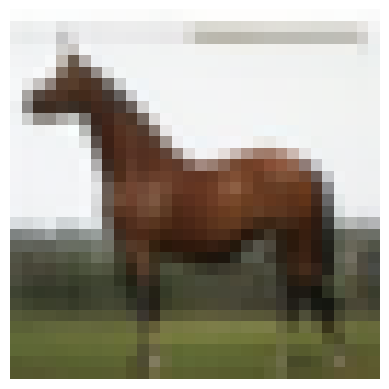

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("run/sample/ddpm_cifar10_pretrained/process_0/10.png")
#img = Image.open("run/sample/ddpm_cifar10_pruned_raw/process_0/10.png")

plt.imshow(img)
plt.axis("off")
plt.show()

## Prune

Creates a pruned model at `run/pruned/ddpm_cifar10_pruned`. The argument is the pruning ratio
(0.1 = light, for a fast test; use 0.3 to reproduce the paper's baseline).

In [ ]:
!bash scripts/prune_ddpm_cifar10.sh 0.1  # pruning ratio

Dataset size: 50000
Loading pretrained model from pretrained/ddpm_ema_cifar10
The config attributes {'rescale_betas_zero_snr': False, 'timestep_spacing': 'leading'} were passed to DDPMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
The config attributes {'attn_norm_num_groups': None, 'downsample_type': 'conv', 'dropout': 0.0, 'mid_block_type': 'UNetMidBlock2D', 'num_train_timesteps': None, 'time_embedding_dim': None, 'upsample_type': 'conv'} were passed to UNet2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.
/usr/local/lib/python3.12/dist-packages/torch_pruning/pruner/algorithms/base_pruner.py:106: UserWarning: channel_groups is deprecated. Please use in_channel_groups and out_channel_groups instead.
  warnings.warn(
Warning! No positional inputs found for a module, assuming batch size is 1.
Accumulating gradients for pruning...
 26% 256/1000 [02:01<05:52,  2.11it/s]
W

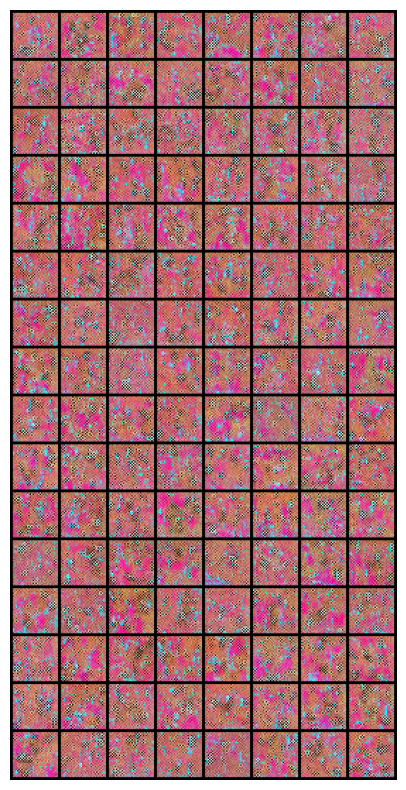

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("run/pruned/ddpm_cifar10_pruned/vis/after_pruning.png")

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

## Fine-tune

Recovers quality lost to pruning and saves to `run/finetuned/ddpm_cifar10_pruned_post_training`.
The argument is the number of iterations (`num_iters`). 3000 is a quick sanity run; the baseline uses 100000.

Checkpoints are written every `save_model_steps` (1000), so Colab persistence / resuming across a dropped
session is possible from the last saved checkpoint.

In [ ]:
!bash scripts/finetune_ddpm_cifar10.sh 10000 12 > train.log 2>&1 & #num_iters, dataloader_num_workers

In [ ]:
!tail -n 20 train.log

Epoch 5:   6%|▋         | 25/391 [00:24<05:50,  1.04it/s, ema_decay=0.995, loss=91.5, lr=0.0002, step=1980]

In [ ]:
!python ddpm_sample.py --output_dir run/sample/ddpm_cifar10_pruned_raw --batch_size 16 --total_samples 16 --pruned_model_ckpt run/finetuned/ddpm_cifar10_pruned_post_training/pruned/unet_pruned.pth --model_path run/finetuned/ddpm_cifar10_pruned_post_training --skip_type uniform


Loading pruned model from run/finetuned/ddpm_cifar10_pruned_post_training/pruned/unet_pruned.pth
The config attributes {'rescale_betas_zero_snr': False, 'timestep_spacing': 'leading'} were passed to DDIMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
The config attributes {'rescale_betas_zero_snr': False, 'timestep_spacing': 'leading'} were passed to DDIMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
Warning! No positional inputs found for a module, assuming batch size is 1.
MACS: 4.253761666 G, Params: 27.559129 M
Samping 16x1=16 images with 1 process(es)
  0% 0/1 [00:00<?, ?it/s]
  0% 0/100 [00:00<?, ?it/s]
  1% 1/100 [00:00<00:10,  9.10it/s]
  5% 5/100 [00:00<00:04, 22.41it/s]
  8% 8/100 [00:00<00:03, 24.88it/s]
 11% 11/100 [00:00<00:03, 26.21it/s]
 14% 14/100 [00:00<00:03, 27.26it/s]
 18% 18/100 [00:00<00:02, 28.42it/s]
 21% 21/100 [00:00<00:02, 28.06

In [ ]:
!ls run/sample/ddpm_cifar10_pruned_raw/process_0

0.png	11.png	13.png	15.png	2.png  4.png  6.png  8.png
10.png	12.png	14.png	1.png	3.png  5.png  7.png  9.png


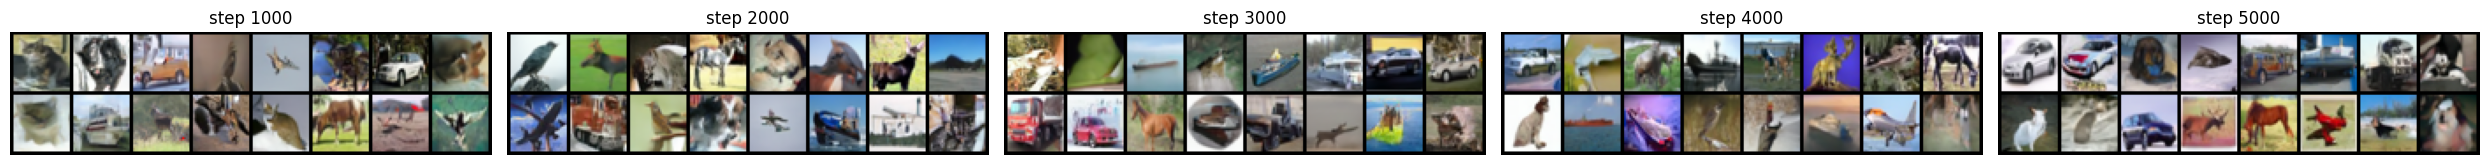

In [ ]:
import glob
import re
from PIL import Image
import matplotlib.pyplot as plt

vis_dir = "run/finetuned/ddpm_cifar10_pruned_post_training/vis"
paths = glob.glob(f"{vis_dir}/iter-*.png")

# sort by the step number embedded in the filename
paths.sort(key=lambda p: int(re.search(r"iter-(\d+)\.png", p).group(1)))

fig, axes = plt.subplots(1, len(paths), figsize=(5 * len(paths), 5))
if len(paths) == 1:
    axes = [axes]

for ax, path in zip(axes, paths):
    step = re.search(r"iter-(\d+)\.png", path).group(1)
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"step {step}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Sample

In [ ]:
# Pruned + finetuned: sample and save images to run/sample/ddpm_cifar10_pruned
!bash scripts/sample_ddpm_cifar10_pruned.sh 2000 > sample1.log 2>&1 &

In [ ]:
!tail -n 20 sample1.log

 86%|████████▌ | 86/100 [00:28<00:04,  3.34it/s]

In [ ]:
# Pretrained baseline: sample and save images to run/sample/ddpm_cifar10_pretrained
!bash scripts/sample_ddpm_cifar10_pretrained.sh 2000 > sample2.log 2>&1 &

In [ ]:
!tail -n 20 sample2.log

 84%|████████▍ | 84/100 [00:30<00:05,  2.77it/s]

## Evaluate (FID)

Using 2000 samples for fast iteration instead of the paper's 50k. Good enough to compare runs
against each other; treat the absolute number as biased/noisy, not literature-comparable.

In [ ]:
# Pre-compute the stats of the CIFAR-10 dataset
!python fid_score.py --save-stats data/cifar10_images run/fid_stats_cifar10.npz --device cuda:0 --batch-size 256

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:02<00:00, 42.7MB/s]
Saving statistics for data/cifar10_images
Found 50000 files.
100% 196/196 [01:27<00:00,  2.25it/s]


In [ ]:
# Compute the FID score of the sampled images
!python fid_score.py run/sample/ddpm_cifar10_pruned run/fid_stats_cifar10.npz --device cuda:0 --batch-size 256

Traceback (most recent call last):
  File "/content/Diff-Pruning/fid_score.py", line 360, in <module>
    main()
  File "/content/Diff-Pruning/fid_score.py", line 349, in main
    fid_value = calculate_fid_given_paths(args.path,
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Diff-Pruning/fid_score.py", line 289, in calculate_fid_given_paths
    raise RuntimeError('Invalid path: %s' % p)
RuntimeError: Invalid path: run/sample/ddpm_cifar10_pruned


## Evaluate (SSIM)

Matched-seed comparison between pretrained and pruned samples (same index = same starting noise).

In [ ]:
!pip install pytorch-msssim

In [ ]:
!python ddpm_exp/compute_ssim.py --path run/sample/ddpm_cifar10_pretrained/process_0 run/sample/ddpm_cifar10_pruned/process_0